In [198]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub


# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [199]:
#NB: Kaggle requires phone verification to use the internet or a GPU. If you haven't done that yet, the cell below will fail
#    This code is only here to check that your internet is enabled. It doesn't do anything else.
#    Here's a help thread on getting your phone number verified: https://www.kaggle.com/product-feedback/135367

import os
os.environ['CUDA_VISIBLE_DEVICES'] = ''  # MUST be before torch import

import socket, warnings, torch
warnings.filterwarnings('ignore', category=DeprecationWarning)

from fastai.vision.all import *
defaults.device = torch.device('cpu')
  # check if GPU is even available

# force CPU if GPU is broken
defaults.device = torch.device('cpu')
try:
    socket.setdefaulttimeout(1)
    socket.socket(socket.AF_INET, socket.SOCK_STREAM).connect(('1.1.1.1', 53))
except socket.error as ex: raise Exception("STOP: No internet. Click '>|' in top right and set 'Internet' switch to on")

In [200]:
# It's a good idea to ensure you're running the latest version of any libraries you need.
# `!pip install -Uqq <libraries>` upgrades to the latest version of <libraries>
# NB: You can safely ignore any warnings or errors pip spits out about running as root or incompatibilities
import os
iskaggle = os.environ.get('KAGGLE_KERNEL_RUN_TYPE', '')

if iskaggle:
    !pip install -Uqq ddgs fastai

In [201]:
## Step 1: Download images of some food images

In [202]:
from ddgs import DDGS
from fastcore.all import * # to import L, faster python version for lists

def search_images(keywords,max_images=200):
    for attempt in range(3):
        try:
            results = DDGS().images(keywords, max_results=max_images)
            print(f"Raw results: {results}")
            img_urls = []
            for result in results:
                img_urls.append(result['image'])
            return img_urls
        except Exception as e:
            print(f'Attempt {attempt+1} failed: {e}')
            time.sleep(5)
    return []
    

In [203]:
urls = search_images('indian food photo',1)
urls[0]

import time, json

Raw results: [{'title': "More Than Seizures: How to Identify Epilepsy's Lesser Known Symptoms ...", 'image': 'https://health.medicaldialogues.in/h-upload/2025/05/17/287181-authored-article-images-96.jpg', 'thumbnail': 'https://ts3.mm.bing.net/th?id=OIP.JzSMKt51RIr7fjOPQ34fuQHaEc&pid=15.1', 'url': 'https://health.medicaldialogues.in/health-topics/brain-health/more-than-seizures-how-to-identify-epilepsys-lesser-known-symptoms-dr-n-varsha-monica-reddy-148450', 'height': '900', 'width': '1500', 'source': 'health.medicaldialogues.in'}]


Raw results: [{'title': 'Download Traditional Thali Platter Indian Food Wallpaper | Wallpapers.com', 'image': 'https://wallpapers.com/images/hd/traditional-thali-platter-indian-food-7ppdmw8bs4n1f36j.jpg', 'thumbnail': 'https://thfvnext.bing.com/th/id/OIP.CMiJRC_8-hwbXo5E2accXgHaEK?cb=thfvnextfalcon&pid=Api', 'url': 'https://wallpapers.com/wallpapers/traditional-thali-platter-indian-food-7ppdmw8bs4n1f36j.html', 'height': 1080, 'width': 1920, 'source': 'Bing'}]
Raw results: [{'title': "Most Popular 24 German Foods (With Pictures!) - Chef's Pencil", 'image': 'https://www.chefspencil.com/wp-content/uploads/All-Aspects-of-German-Cuisine.jpg', 'thumbnail': 'https://ts3.mm.bing.net/th?id=OIP.NeNRYInKJTikVOwYR1SAlgHaE8&pid=15.1', 'url': 'https://www.chefspencil.com/most-popular-24-german-foods/', 'height': '800', 'width': '1200', 'source': 'chefspencil.com'}]


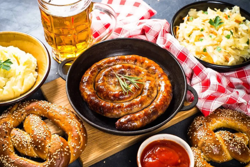

In [204]:
from fastdownload import download_url
from fastai.vision.all import *

download_url(search_images('indian food photo', 1)[0], 'indian-food.jpg', show_progress=0)
time.sleep(5)
download_url(search_images('german food photo', 1)[0], 'german-food.jpg', show_progress=0)
time.sleep(5)

im_indian = Image.open('indian-food.jpg')
im_german = Image.open('german-food.jpg')

im_indian.to_thumb(250)
im_german.to_thumb(250)


In [205]:
## Step 2: Group the images into different folders


In [206]:
food_type = ['indian food', 'german food']
path = Path('food')

for o in food_type:
    dest = path/o
    dest.mkdir(exist_ok=True, parents=True)
    download_images(dest, urls=search_images(f'{o} photo',100))
    time.sleep(5)
    resize_image(dest, max_size=400, dest=dest)

Raw results: [{'title': '[100+] Indian Food Wallpapers | Wallpapers.com', 'image': 'https://wallpapers.com/images/hd/traditional-thali-platter-indian-food-7ppdmw8bs4n1f36j.jpg', 'thumbnail': 'https://ts1.mm.bing.net/th?id=OIP.CMiJRC_8-hwbXo5E2accXgHaEK&pid=15.1', 'url': 'https://wallpapers.com/indian-food', 'height': '1080', 'width': '1920', 'source': ''}, {'title': 'Typical Indian Dinner', 'image': 'https://www.kayak.co.uk/news/wp-content/uploads/sites/5/2022/10/THEME_FOOD_INDIAN-CUISINE-GettyImages-526749337-1.jpg', 'thumbnail': 'https://ts1.mm.bing.net/th?id=OIP.8j3vOHM5HGL6RlsAFlA3bgHaFD&pid=15.1', 'url': 'https://ar.inspiredpencil.com/pictures-2023/typical-indian-dinner', 'height': '1312', 'width': '1920', 'source': ''}, {'title': 'Traditional Indian Food Dishes', 'image': 'https://media.restless.co.uk/uploads/2022/01/9-authentic-and-easy-indian-recipes-to-try-at-home.jpg', 'thumbnail': 'https://ts4.mm.bing.net/th?id=OIP.ExK4JX3Ojstt55NtKSMoZQHaE8&pid=15.1', 'url': 'https://fity.c

In [207]:
## Step 3: Train the model

In [208]:
failed = verify_images(get_image_files(path))
failed.map(Path.unlink)
len(failed)


1

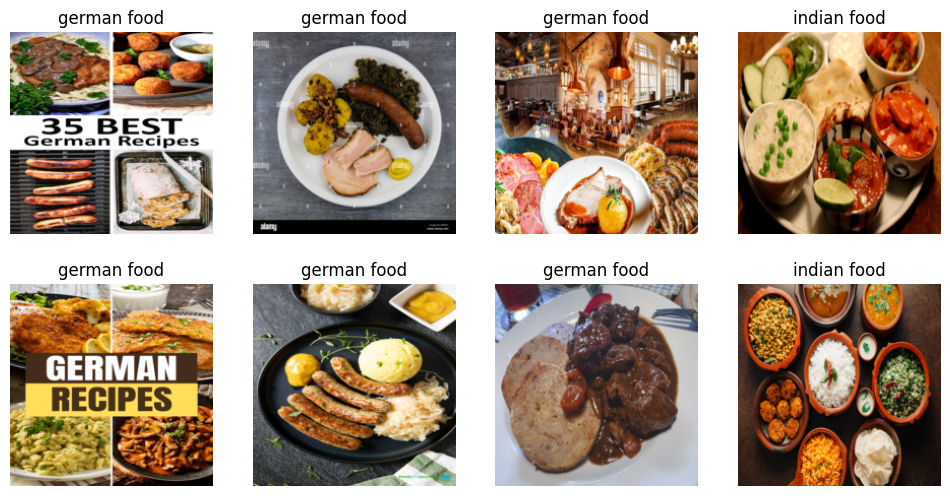

In [209]:
#1) Think of DataBlock as a recipe for preparing your dataset.

# You tell FastAI:
# What your inputs are
# What your labels are
# Where to find the files
# How to split train/validation data
# Any preprocessing steps

dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2,seed=47),
    get_y=parent_label, #3
    item_tfms=[Resize(200,method='squish')] # transformations to the images
).dataloaders(path,bs=32) #2

# 2) bs=32:
# (images shape)
# (32, 3, 200, 200)

# Meaning:
# 32 images
# 3 color channels (RGB)
# 200×200 size


# 3) parent_label:
# For: cat1.jpg
# Parent folder: cat
# So label becomes: cat

dls.show_batch(max_n=8)

In [210]:
learner = vision_learner(dls, resnet18, metrics=error_rate)
learner.fine_tune(3)

# number of epochs (how many times to go through all your images)

# With tabular data (fit):

# You train a model from scratch
# All layers learn from zero
# You just call fit and it trains for however many epochs


# With images (fine_tune):

# The model (resnet18) is already pretrained — it was trained on 1.2 million images called ImageNet
# It already knows how to detect edges, shapes, textures, eyes, fur etc.
# You don't want to throw that knowledge away and start from scratch

# So fine_tune does it in 2 stages:
# Stage 1 — Freeze (1 epoch):
# [pretrained layers - FROZEN ❄️] → [your new last layer - TRAINING 🔥]

# The pretrained layers are locked/frozen — their weights don't change
# Only the last layer is trained — it learns YOUR specific categories (cat/dog/food etc.)
# This is fast and safe

# Stage 2 — Unfreeze (remaining epochs):
# [pretrained layers - TRAINING 🔥] → [your new last layer - TRAINING 🔥]

# Now ALL layers are unlocked and train together
# The pretrained knowledge gets fine-tuned for your specific problem
# Uses a very small learning rate so it doesn't destroy the pretrained knowledge


# Why not just use fit for images?

# Training from scratch needs millions of images and days of compute
# fine_tune gets you great results with just ~100 images in minutes
# This concept is called Transfer Learning — transferring knowledge from one task to another

epoch,train_loss,valid_loss,error_rate,time
0,1.955797,1.614969,0.609756,00:32


epoch,train_loss,valid_loss,error_rate,time
0,0.812920,1.079098,0.317073,00:42
1,0.569125,0.686700,0.219512,00:43
2,0.429723,0.587517,0.170732,00:43


In [211]:
which_food, _, prob = learner.predict(PILImage.create('indian-food.jpg'))
print(f'this is {which_food}')
print(f'probability: {prob.max():.4f}')  # use max() to get the winning category's probability

which_food, _, prob = learner.predict(PILImage.create('german-food.jpg'))
print(f'this is {which_food}')
print(f'probability: {prob.max():.4f}')  # use max() to get the winning category's probability


this is indian food
probability: 0.8863


this is german food
probability: 0.9895
